In [2]:
import requests
import pandas as pd
import plotly.express as px

In [3]:
# IMF  = Interplanetary Magnetic Field

# Measured in Bx, By, Bz..

# Bx = sun to earth direction
# By = Sideways Magnetic Field
# Bz > 0 Earth Resists Interaction
# Bz < 0 Earth Connects more easily

In [4]:
url  = "https://services.swpc.noaa.gov/products/solar-wind/mag-7-day.json"

response  = requests.get(url)

print(response.status_code)

200


In [5]:
data = response.json()

print(type(data))
print(len(data))

<class 'list'>
9819


In [6]:
print(data[0])

['time_tag', 'bx_gsm', 'by_gsm', 'bz_gsm', 'lon_gsm', 'lat_gsm', 'bt']


In [7]:
print(data[1])

['2026-06-14 11:16:00.000', '5.53', '0.36', '0.03', '3.72', '0.34', '5.54']


In [8]:
df = pd.DataFrame(data[1:], columns =data[0])
df.head()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
0,2026-06-14 11:16:00.000,5.53,0.36,0.03,3.72,0.34,5.54
1,2026-06-14 11:17:00.000,5.29,0.37,0.04,3.98,0.47,5.30
2,2026-06-14 11:18:00.000,4.73,-1.28,-1.26,344.85,-14.40,5.22
3,2026-06-14 11:19:00.000,4.71,-1.76,-1.82,339.53,-19.90,5.37
4,2026-06-14 11:20:00.000,5.05,-1.29,-1.38,345.61,-14.83,5.40


In [9]:
print(type(data))

<class 'list'>


In [10]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9818 entries, 0 to 9817
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   time_tag  9818 non-null   str  
 1   bx_gsm    9818 non-null   str  
 2   by_gsm    9818 non-null   str  
 3   bz_gsm    9818 non-null   str  
 4   lon_gsm   9818 non-null   str  
 5   lat_gsm   9818 non-null   str  
 6   bt        9818 non-null   str  
dtypes: str(7)
memory usage: 537.1 KB
None


In [11]:
df["time_tag"] = pd.to_datetime(df["time_tag"])

numeric_cols = ["bx_gsm","by_gsm","bz_gsm","lon_gsm","lat_gsm","bt"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors = "coerce")

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9818 entries, 0 to 9817
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time_tag  9818 non-null   datetime64[us]
 1   bx_gsm    9818 non-null   float64       
 2   by_gsm    9818 non-null   float64       
 3   bz_gsm    9818 non-null   float64       
 4   lon_gsm   9818 non-null   float64       
 5   lat_gsm   9818 non-null   float64       
 6   bt        9818 non-null   float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 537.1 KB


In [13]:
df.describe()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
count,9818,9818.000000,9818.000000,9818.000000,9818.000000,9818.000000,9818.000000
mean,2026-06-18 00:02:53.937665,-0.432277,0.848694,0.632681,166.548006,5.364280,6.004446
min,2026-06-14 11:16:00,-9.650000,-8.290000,-7.510000,0.030000,-87.120000,0.620000
25%,2026-06-16 06:52:15,-3.260000,-2.480000,-1.480000,84.752500,-15.727500,4.710000
50%,2026-06-18 00:14:30,0.020000,1.200000,0.460000,141.845000,4.970000,6.000000
75%,2026-06-19 17:42:45,2.610000,4.070000,2.390000,264.422500,25.735000,7.070000
max,2026-06-21 11:12:00,6.280000,9.930000,11.400000,359.970000,87.170000,12.000000
std,NaN,3.555717,3.950641,3.099931,103.557156,32.202722,1.873839


In [14]:
df.loc[df["bz_gsm"].idxmin()]

time_tag    2026-06-16 13:47:00
bx_gsm                     1.73
by_gsm                     -0.6
bz_gsm                    -7.51
lon_gsm                   340.9
lat_gsm                  -76.26
bt                         7.75
Name: 2856, dtype: object

In [15]:
# usally at daytime earths magnetic field generally points northward
# therefore negative IMF Bz means southward 
# Opposite magnetic fields meeting leads to magnetic reconnection which make energy transfer easy into the earth

In [16]:
(df["bz_gsm"]<0).sum()

np.int64(4138)

In [17]:
(df["bz_gsm"]>0).sum()

np.int64(5660)

In [18]:
(df["bz_gsm"]==0).sum()

np.int64(20)

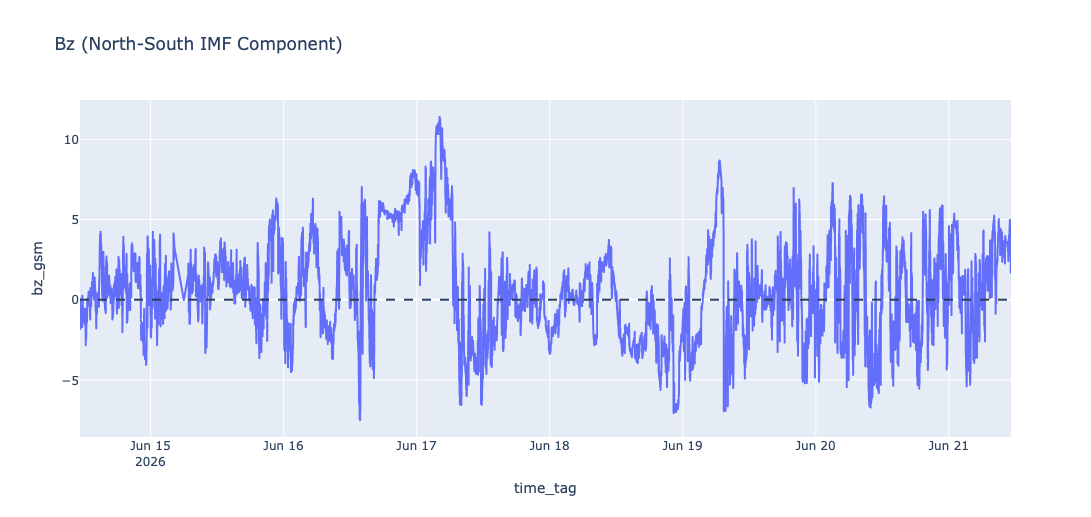

In [19]:


fig = px.line(
    df,
    x="time_tag",
    y="bz_gsm",
    title="Bz (North-South IMF Component)"
)

fig.update_layout(
    width=1200,
    height=500
)
fig.add_hline(
    y=0,
    line_dash="dash"
)

fig

In [20]:
df["bt"].describe()

count    9818.000000
mean        6.004446
std         1.873839
min         0.620000
25%         4.710000
50%         6.000000
75%         7.070000
max        12.000000
Name: bt, dtype: float64

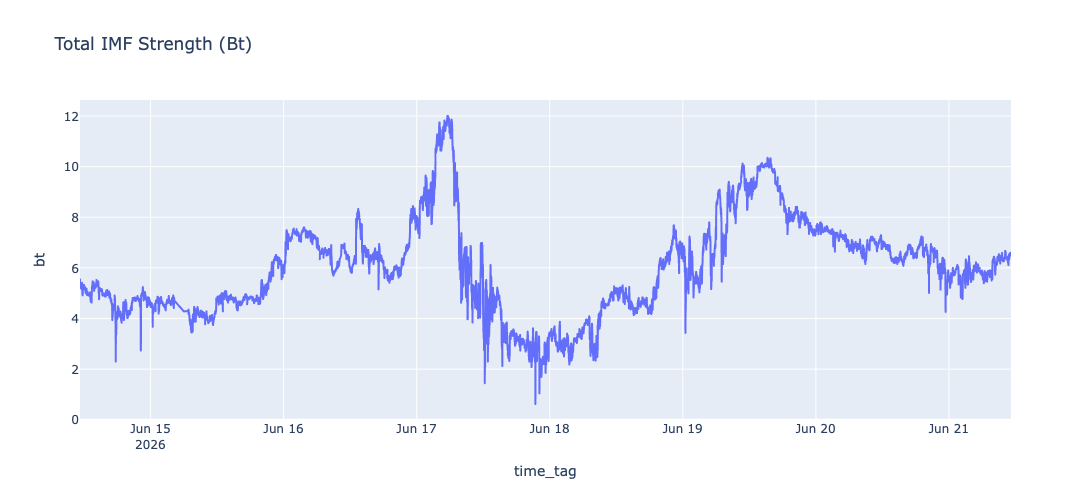

In [21]:
fig = px.line(
    df,
    x="time_tag",
    y="bt",
    title="Total IMF Strength (Bt)"
)

fig.update_layout(
    width=1200,
    height=500
)

fig

In [22]:
# Direction Matters Bz
# Strength Matters Bt

In [23]:
df.loc[df["bt"].idxmax()]

time_tag    2026-06-17 05:32:00
bx_gsm                      3.1
by_gsm                     8.77
bz_gsm                     7.58
lon_gsm                   70.55
lat_gsm                    39.2
bt                         12.0
Name: 3800, dtype: object

In [24]:
#Strong field alone does not imply
# geomagnetic storm potential.

# Bz direction remains critical


In [25]:
df[["bx_gsm","by_gsm","bz_gsm","bt"]].corr()

,bx_gsm,by_gsm,bz_gsm,bt
bx_gsm,1.000000,-0.262688,-0.054944,-0.510199
by_gsm,-0.262688,1.000000,-0.033517,0.316594
bz_gsm,-0.054944,-0.033517,1.000000,0.246286
bt,-0.510199,0.316594,0.246286,1.000000


In [26]:
# Bz behaves largely Independent (Bx & By)

# Day 4 Bonus Analysis

In [27]:
solar_url = "https://services.swpc.noaa.gov/products/solar-wind/plasma-7-day.json"

solar_response = requests.get(solar_url)

solar_data = solar_response.json()

In [28]:
solar_df = pd.DataFrame(
    solar_data[1:],
    columns=solar_data[0]
)

In [29]:
solar_df.head()

,time_tag,density,speed,temperature
0,2026-06-14 11:17:00.000,12.10,501.3,265729
1,2026-06-14 11:18:00.000,10.95,506.0,267877
2,2026-06-14 11:19:00.000,9.77,504.2,295260
3,2026-06-14 11:20:00.000,9.83,502.9,302342
4,2026-06-14 11:21:00.000,9.84,502.2,312274


In [30]:
solar_df["time_tag"] = pd.to_datetime(solar_df["time_tag"])

for col in ["density", "speed", "temperature"]:
    solar_df[col] = pd.to_numeric(
        solar_df[col],
        errors="coerce"
    )

In [31]:
solar_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9623 entries, 0 to 9622
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time_tag     9623 non-null   datetime64[us]
 1   density      9623 non-null   float64       
 2   speed        9623 non-null   float64       
 3   temperature  9623 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(1)
memory usage: 300.8 KB


In [32]:
merged_df = pd.merge(
    solar_df,
    df,
    on="time_tag",
    how="inner"
)

In [33]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9622 entries, 0 to 9621
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   time_tag     9622 non-null   datetime64[us]
 1   density      9622 non-null   float64       
 2   speed        9622 non-null   float64       
 3   temperature  9622 non-null   int64         
 4   bx_gsm       9622 non-null   float64       
 5   by_gsm       9622 non-null   float64       
 6   bz_gsm       9622 non-null   float64       
 7   lon_gsm      9622 non-null   float64       
 8   lat_gsm      9622 non-null   float64       
 9   bt           9622 non-null   float64       
dtypes: datetime64[us](1), float64(8), int64(1)
memory usage: 751.8 KB


In [34]:
merged_df[
    [
        "density",
        "speed",
        "temperature",
        "bx_gsm",
        "by_gsm",
        "bz_gsm",
        "bt"
    ]
].corr()

,density,speed,temperature,bx_gsm,by_gsm,bz_gsm,bt
density,1.000000,0.053038,0.001618,0.194493,0.005668,0.241242,0.125328
speed,0.053038,1.000000,0.808105,0.351824,-0.489149,0.027774,-0.328503
temperature,0.001618,0.808105,1.000000,0.182302,-0.408870,-0.194996,-0.302680
bx_gsm,0.194493,0.351824,0.182302,1.000000,-0.255806,-0.056887,-0.523307
by_gsm,0.005668,-0.489149,-0.408870,-0.255806,1.000000,-0.040979,0.322597
bz_gsm,0.241242,0.027774,-0.194996,-0.056887,-0.040979,1.000000,0.246102
bt,0.125328,-0.328503,-0.302680,-0.523307,0.322597,0.246102,1.000000


Merged Solar Wind and IMF analysis showed that
solar wind speed, density, and temperature have
little relationship with Bz orientation.

The strongest relationship observed was between
speed and temperature (0.81).

This suggests that plasma properties and magnetic
field orientation should be analyzed separately
when assessing space weather conditions.

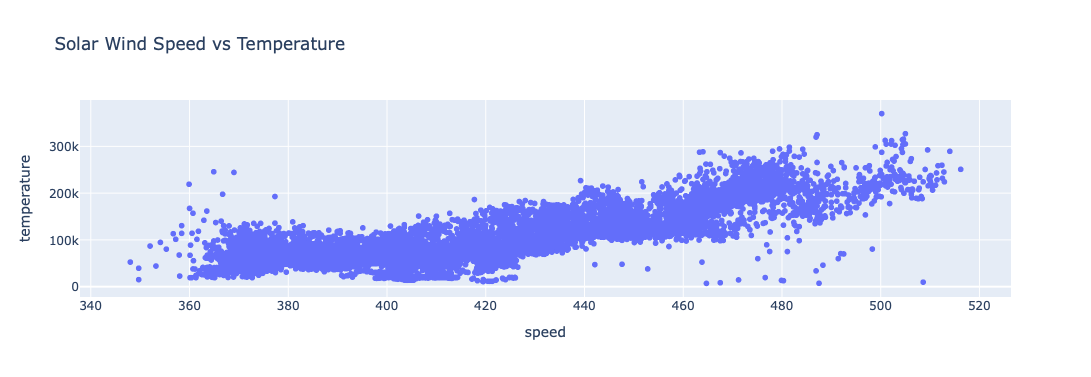

In [35]:
import plotly.express as px

fig = px.scatter(
    merged_df,
    x="speed",
    y="temperature",
    title="Solar Wind Speed vs Temperature"
)

fig

# Bz Persistance


In [36]:
df["negative_bz"] = df["bz_gsm"] < 0

In [37]:
groups = (df["negative_bz"] != df["negative_bz"].shift()).cumsum()

In [38]:
df["group"] = groups

In [39]:
negative_intervals = (
    df[df["negative_bz"]]
    .groupby("group")
    .size()
)

In [40]:
negative_intervals.max()

np.int64(318)

In [41]:
longest_group = negative_intervals.idxmax()

longest_group

np.int64(356)

In [42]:
longest_event = df[df["group"] == longest_group]

longest_event.head()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt,negative_bz,group
5605,2026-06-18 12:06:00,5.06,0.01,-0.27,0.09,-3.02,5.07,True,356
5606,2026-06-18 12:07:00,5.04,-0.24,-0.54,357.27,-6.10,5.07,True,356
5607,2026-06-18 12:08:00,4.99,-0.40,-0.57,355.44,-6.45,5.04,True,356
5608,2026-06-18 12:09:00,4.96,-0.67,-0.55,352.35,-6.30,5.03,True,356
5609,2026-06-18 12:10:00,4.94,-0.99,-0.49,348.71,-5.58,5.06,True,356


In [43]:
longest_event.tail()

,time_tag,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt,negative_bz,group
5918,2026-06-18 17:22:00,1.98,3.02,-2.99,56.69,-39.65,4.72,True,356
5919,2026-06-18 17:23:00,2.03,3.01,-3.02,56.05,-39.74,4.73,True,356
5920,2026-06-18 17:24:00,1.89,3.22,-2.81,59.62,-36.94,4.67,True,356
5921,2026-06-18 17:25:00,2.10,3.13,-2.74,56.10,-36.04,4.67,True,356
5922,2026-06-18 17:26:00,3.37,3.33,-0.58,44.65,-6.95,4.82,True,356


In [44]:
start_time = longest_event["time_tag"].min()
end_time = longest_event["time_tag"].max()

print(start_time)
print(end_time)

2026-06-18 12:06:00
2026-06-18 17:26:00


In [46]:
duration = end_time - start_time

print(duration)

0 days 05:20:00


# KP Index Analysis

In [47]:
merged_df[
    (merged_df["time_tag"] >= "2026-06-18 21:00")
    &
    (merged_df["time_tag"] <= "2026-06-19 00:00")
]

,time_tag,density,speed,temperature,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
5946,2026-06-18 21:00:00,6.57,368.0,36513,0.77,5.49,-2.80,82.01,-26.76,6.21
5947,2026-06-18 21:01:00,6.54,369.1,38030,0.74,5.46,-2.89,82.31,-27.69,6.23
5948,2026-06-18 21:02:00,7.01,371.3,35256,1.17,5.34,-2.94,77.67,-28.24,6.21
5949,2026-06-18 21:03:00,6.45,369.8,38942,1.05,5.47,-2.90,79.14,-27.51,6.29
5950,2026-06-18 21:04:00,6.40,369.3,37313,1.37,5.34,-3.10,75.59,-29.35,6.32
...,...,...,...,...,...,...,...,...,...,...
6122,2026-06-18 23:56:00,8.65,372.4,32284,4.06,4.94,-1.83,50.52,-15.98,6.66
6123,2026-06-18 23:57:00,7.68,373.1,38834,3.85,5.44,-1.73,54.72,-14.54,6.88
6124,2026-06-18 23:58:00,8.07,372.0,22356,4.24,4.90,-1.68,49.14,-14.51,6.72
6125,2026-06-18 23:59:00,8.94,374.8,37083,4.54,4.63,-1.44,45.59,-12.51,6.64


In [48]:
merged_df.loc[
    merged_df["time_tag"] == "2026-06-19 00:00:00"
]

,time_tag,density,speed,temperature,bx_gsm,by_gsm,bz_gsm,lon_gsm,lat_gsm,bt
6126,2026-06-19,8.88,374.6,35993,4.43,4.68,-1.29,46.54,-11.31,6.57


In [49]:
merged_df[
    (merged_df["time_tag"] >= "2026-06-18 18:00")
    &
    (merged_df["time_tag"] <= "2026-06-19 03:00")
][["time_tag","speed","density","temperature","bz_gsm","bt"]].describe()

,time_tag,speed,density,temperature,bz_gsm,bt
count,541,541.000000,541.000000,541.000000,541.000000,541.000000
mean,2026-06-18 22:30:00,371.697782,7.371072,49575.480591,-2.869519,5.994104
min,2026-06-18 18:00:00,356.700000,4.010000,19212.000000,-7.070000,3.430000
25%,2026-06-18 20:15:00,367.700000,6.270000,36006.000000,-3.940000,5.440000
50%,2026-06-18 22:30:00,371.400000,7.140000,41426.000000,-2.810000,6.110000
75%,2026-06-19 00:45:00,375.600000,8.380000,64215.000000,-1.620000,6.620000
max,2026-06-19 03:00:00,389.300000,12.940000,120138.000000,2.650000,7.680000
std,NaN,5.587684,1.511103,19164.174601,2.019868,0.820246
